In [1]:
#Import packages 

import numpy as np 
import pandas as pd 
import json 
import glob
import os
import csv
from statsmodels.tsa.seasonal import seasonal_decompose

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import gc
from pathlib import Path
import warnings


In [2]:
DATA_DIR  = Path('../files')
PLOTS_DIR = Path('../outputs/plots')
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
(PLOTS_DIR / 'supplementary').mkdir(exist_ok=True)
(PLOTS_DIR / 'spatial').mkdir(exist_ok=True)

In [3]:
warnings.filterwarnings('ignore', category=FutureWarning)

In [4]:
# =====================================================
# Detailed season classification
# =====================================================

def assign_season(month):
    if month in [12, 1, 2, 3]:
        return 'Dry_Season'
    elif month in [4, 5, 6, 7]:
        return 'Major_Rainy_Season'
    elif month in [9, 10, 11]:
        return 'Minor_Rainy_Season'
    else:
        return 'Transition_Season'


# =====================================================
# Simpler season classification
# =====================================================

def assign_simple_season(month):
    if month in [12, 1, 2, 3]:
        return 'Dry_Season'
    elif month in [4, 5, 6, 7, 9, 10, 11]:
        return 'Rainy_Season'
    else:
        return 'Transition_Season'

### Sensor - CESI Mapping 

### using `rev1` version --> (2 CESI clusters instead of 3)  

In [5]:
### CESI Mapping here 
sensor_cesi_mapping = pd.read_csv(DATA_DIR / 'miscellaneous/sensor_cesi_mapping_rev1.csv').drop(columns=['Unnamed: 0'])

## *** Reading processed hourly data 

### `2022` & `2023` + `concat` 

In [6]:
processed_hourly_voltage_df_22 = pd.read_csv(DATA_DIR / 'processed_undervolt_data/undervolt_hourly_voltages_df_22.csv')

processed_hourly_voltage_df_23 = pd.read_csv(DATA_DIR / 'processed_undervolt_data/undervolt_hourly_voltages_df_23.csv')

combined_hourly_voltage_df = pd.concat([processed_hourly_voltage_df_22, processed_hourly_voltage_df_23], ignore_index=True)

### keep only sensors of interest 

In [7]:
sensor_of_interest_list = pd.read_csv(DATA_DIR / 'miscellaneous/common_sensors_22_23_rev4.csv')['respondent_id'].unique().tolist()

combined_hourly_voltage_df = combined_hourly_voltage_df[combined_hourly_voltage_df['sensor_id'].isin(sensor_of_interest_list)].reset_index(drop=True)

## add CESI mapping 
combined_hourly_voltage_df = combined_hourly_voltage_df.merge(sensor_cesi_mapping, on = 'sensor_id')

### *** Reading hourly temp data 

In [8]:
hourly_temperature = pd.read_csv(DATA_DIR / 'miscellaneous/hourly_temp_sites_of_interest.csv').drop(columns = ['Unnamed: 0'])

### *** Merging with voltage data 

In [9]:
combined_hourly_voltage_df = combined_hourly_voltage_df.merge(hourly_temperature, on = ['time', 'site_id'])

combined_hourly_voltage_df = combined_hourly_voltage_df[['time', 'ea_code9ch',  'site_id', 'sensor_id', 'voltage', 'Temp', 'cesi_level']]

### Add season 

In [10]:
# Make sure time is datetime
combined_hourly_voltage_df['time'] = pd.to_datetime(
    combined_hourly_voltage_df['time']
)

# Extract month
combined_hourly_voltage_df['Month'] = (
    combined_hourly_voltage_df['time'].dt.month
)

# =====================================================
# Detailed season classification
# =====================================================

combined_hourly_voltage_df['season_detailed'] = (
    combined_hourly_voltage_df['Month']
    .apply(assign_season)
)

# =====================================================
# Simpler season classification
# =====================================================

combined_hourly_voltage_df['season_simple'] = (
    combined_hourly_voltage_df['Month']
    .apply(assign_simple_season)
)

In [11]:
combined_hourly_voltage_df.head()

,time,ea_code9ch,site_id,sensor_id,voltage,Temp,cesi_level,Month,season_detailed,season_simple
0,2022-01-01 00:00:00,30410207,1,bb3ff846,236.64,26.220942,Low,1,Dry_Season,Dry_Season
1,2022-01-01 01:00:00,30410207,1,bb3ff846,235.38,26.099647,Low,1,Dry_Season,Dry_Season
2,2022-01-01 02:00:00,30410207,1,bb3ff846,235.45,25.953452,Low,1,Dry_Season,Dry_Season
3,2022-01-01 03:00:00,30410207,1,bb3ff846,236.54,25.779780,Low,1,Dry_Season,Dry_Season
4,2022-01-01 04:00:00,30410207,1,bb3ff846,237.72,25.564437,Low,1,Dry_Season,Dry_Season


### Summary Stats -> Hourly Voltages 

In [12]:
percentiles_df = (
    combined_hourly_voltage_df['voltage']
    .quantile([0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
    .reset_index()
)

percentiles_df.columns = ['percentile', 'voltage']
percentiles_df['percentile'] = (
    percentiles_df['percentile'] * 100
).astype(int)

In [13]:
percentiles_df

,percentile,voltage
0,1,183.14
1,5,204.31
2,10,212.90
3,25,224.16
4,50,234.09
5,75,241.94
6,90,248.47
7,95,252.19
8,99,258.46


In [14]:
combined_hourly_voltage_df['voltage'].quantile(0.062)

np.float64(207.02)

### low voltage threshold: 207V (undervolt threshold): 6.2 percentile 

## *** Plots 

### Daily median temp & voltages 

In [15]:
def plot_daily_voltage_temp_stacked_monthly(
    df,
    start_time=None,
    end_time=None,
    site_ids=None,
    cesi_level=None,
    voltage_col='voltage',
    temp_col='Temp',
    center='median',
    lower_q=0.10,
    upper_q=0.90,
    ignore_zero=True,
    figsize=(15, 8),
    voltage_line_color='#08519c',
    voltage_band_color='#9ecae1',
    temp_line_color='#f16913',
    temp_band_color='#fdd0a2',
    linewidth=2.5,
    alpha_band=0.25,
    voltage_ylabel='Voltage (V)',
    temp_ylabel='Temperature (°C)',
    xlabel='Month-Year',
    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.5,
    show_temp_threshold=True,
    temp_threshold=32,
    temp_threshold_color='darkred',
    temp_threshold_linestyle='--',
    temp_threshold_linewidth=1.5,
    temp_threshold_label='WHO Thermal Comfort Threshold (32°C)',
    voltage_ylim=None,
    temp_ylim=None,
    legend_loc='upper left',
    legend_bbox=None,
    sharex=True,
    show_every_n_months=2,
    tick_fontsize=11,
    rotate_xticks=0,
    xlabel_y=-0.02,
    save_path=None,
    dpi=300
):
    import pandas as pd
    import matplotlib.pyplot as plt

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    # -------------------------
    # Filtering
    # -------------------------
    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    if cesi_level is not None:
        plot_df = plot_df[plot_df['cesi_level'] == cesi_level]

    if start_time is not None:
        plot_df = plot_df[plot_df['time'] >= pd.to_datetime(start_time)]

    if end_time is not None:
        plot_df = plot_df[plot_df['time'] <= pd.to_datetime(end_time)]

    if ignore_zero:
        plot_df = plot_df[plot_df[voltage_col] != 0]

    plot_df = plot_df.dropna(subset=['time'])
    plot_df['date'] = plot_df['time'].dt.floor('D')

    if center not in ['mean', 'median']:
        raise ValueError("center must be either 'mean' or 'median'")

    percentile_label = (
        f'{int(lower_q * 100)}th - '
        f'{int(upper_q * 100)}th percentile'
    )

    # -------------------------
    # Daily voltage summaries
    # -------------------------
    voltage_grouped = (
        plot_df
        .dropna(subset=[voltage_col])
        .groupby('date')[voltage_col]
        .agg(
            voltage_center=center,
            voltage_lower=lambda x: x.quantile(lower_q),
            voltage_upper=lambda x: x.quantile(upper_q),
            voltage_n='count'
        )
        .reset_index()
    )

    # -------------------------
    # Daily temperature summaries
    # -------------------------
    temp_grouped = (
        plot_df
        .dropna(subset=[temp_col])
        .groupby('date')[temp_col]
        .agg(
            temp_center=center,
            temp_lower=lambda x: x.quantile(lower_q),
            temp_upper=lambda x: x.quantile(upper_q),
            temp_n='count'
        )
        .reset_index()
    )

    # -------------------------
    # Build monthly x-tick positions and labels
    # -------------------------
    all_dates = pd.concat([
        voltage_grouped['date'],
        temp_grouped['date']
    ]).drop_duplicates().sort_values()

    month_starts = (
        all_dates
        .to_frame(name='date')
        .assign(month_floor=lambda d: d['date'].dt.to_period('M').dt.to_timestamp())
        .drop_duplicates('month_floor')
        .sort_values('month_floor')
        ['month_floor']
        .reset_index(drop=True)
    )

    tick_positions = month_starts.tolist()
    tick_labels = []

    for i, dt in enumerate(month_starts):
        if i % show_every_n_months == 0:
            tick_labels.append(dt.strftime('%b-%y'))
        else:
            tick_labels.append('')

    # -------------------------
    # Plot
    # -------------------------
    fig, axes = plt.subplots(
        2, 1,
        figsize=figsize,
        sharex=sharex
    )

    ax_temp = axes[0]
    ax_volt = axes[1]

    # =================================================
    # TEMPERATURE SUBPLOT
    # =================================================
    ax_temp.fill_between(
        temp_grouped['date'],
        temp_grouped['temp_lower'],
        temp_grouped['temp_upper'],
        color=temp_band_color,
        alpha=alpha_band,
        label=percentile_label
    )

    ax_temp.plot(
        temp_grouped['date'],
        temp_grouped['temp_center'],
        color=temp_line_color,
        linewidth=linewidth,
        label=f'Daily Temperature {center.capitalize()}'
    )

    if show_temp_threshold:
        ax_temp.axhline(
            temp_threshold,
            color=temp_threshold_color,
            linestyle=temp_threshold_linestyle,
            linewidth=temp_threshold_linewidth,
            alpha=0.9,
            label=temp_threshold_label
        )

    ax_temp.set_ylabel(
        temp_ylabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15,
        color=temp_line_color
    )

    ax_temp.tick_params(axis='y', colors=temp_line_color, labelsize=11, width=2)
    ax_temp.tick_params(axis='x', labelsize=tick_fontsize)

    ax_temp.spines['left'].set_color(temp_line_color)
    ax_temp.spines['left'].set_linewidth(1.5)

    if temp_ylim is not None:
        ax_temp.set_ylim(temp_ylim)

    # Temperature legend order
    temp_handles, temp_labels = ax_temp.get_legend_handles_labels()

    temp_order = [
        temp_labels.index(f'Daily Temperature {center.capitalize()}'),
        temp_labels.index(percentile_label)
    ]

    if show_temp_threshold:
        temp_order.append(temp_labels.index(temp_threshold_label))

    ax_temp.legend(
        [temp_handles[i] for i in temp_order],
        [temp_labels[i] for i in temp_order],
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    # =================================================
    # VOLTAGE SUBPLOT
    # =================================================
    ax_volt.fill_between(
        voltage_grouped['date'],
        voltage_grouped['voltage_lower'],
        voltage_grouped['voltage_upper'],
        color=voltage_band_color,
        alpha=alpha_band,
        label=percentile_label
    )

    ax_volt.plot(
        voltage_grouped['date'],
        voltage_grouped['voltage_center'],
        color=voltage_line_color,
        linewidth=linewidth,
        label=f'Daily Voltage {center.capitalize()}'
    )

    if show_voltage_bounds:
        lower_bound = nominal_voltage * (1 - tolerance)

        ax_volt.axhline(
            lower_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label=f'Low Voltage Threshold ({lower_bound:.0f} V)'
        )

    ax_volt.set_ylabel(
        voltage_ylabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15,
        color=voltage_line_color
    )

    ax_volt.tick_params(axis='y', colors=voltage_line_color, labelsize=11, width=2)
    ax_volt.tick_params(axis='x', labelsize=tick_fontsize)

    ax_volt.spines['left'].set_color(voltage_line_color)
    ax_volt.spines['left'].set_linewidth(1.5)

    if voltage_ylim is not None:
        ax_volt.set_ylim(voltage_ylim)

    # Voltage legend order
    volt_handles, volt_labels = ax_volt.get_legend_handles_labels()

    volt_order = [
        volt_labels.index(f'Daily Voltage {center.capitalize()}'),
        volt_labels.index(percentile_label)
    ]

    if show_voltage_bounds:
        volt_order.append(
            volt_labels.index(f'Low Voltage Threshold ({lower_bound:.0f} V)')
        )

    ax_volt.legend(
        [volt_handles[i] for i in volt_order],
        [volt_labels[i] for i in volt_order],
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    # -------------------------
    # Apply monthly x-ticks to bottom axis
    # -------------------------
    ax_volt.set_xticks(tick_positions)
    ax_volt.set_xticklabels(
        tick_labels,
        fontsize=tick_fontsize,
        fontweight='normal',
        rotation=rotate_xticks
    )

    # -------------------------
    # Clean styling
    # -------------------------
    for ax in axes:
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    if cesi_level is not None:
        fig.suptitle(
            f'{cesi_level} CESI',
            fontsize=15,
            fontweight='bold',
            y=1.02
        )

    # -------------------------
    # tight_layout first, then anchor xlabel to axes center
    # -------------------------
    plt.tight_layout()

    ax_volt_pos = ax_volt.get_position()
    axes_center = (ax_volt_pos.x0 + ax_volt_pos.x1) / 2

    fig.text(
        axes_center,
        xlabel_y,
        xlabel,
        fontsize=13,
        fontweight='bold',
        ha='center',
        va='top',
        transform=fig.transFigure
    )

    if save_path is not None:
        fig.savefig(save_path, dpi=dpi, bbox_inches='tight')

    plt.show()

    return voltage_grouped, temp_grouped

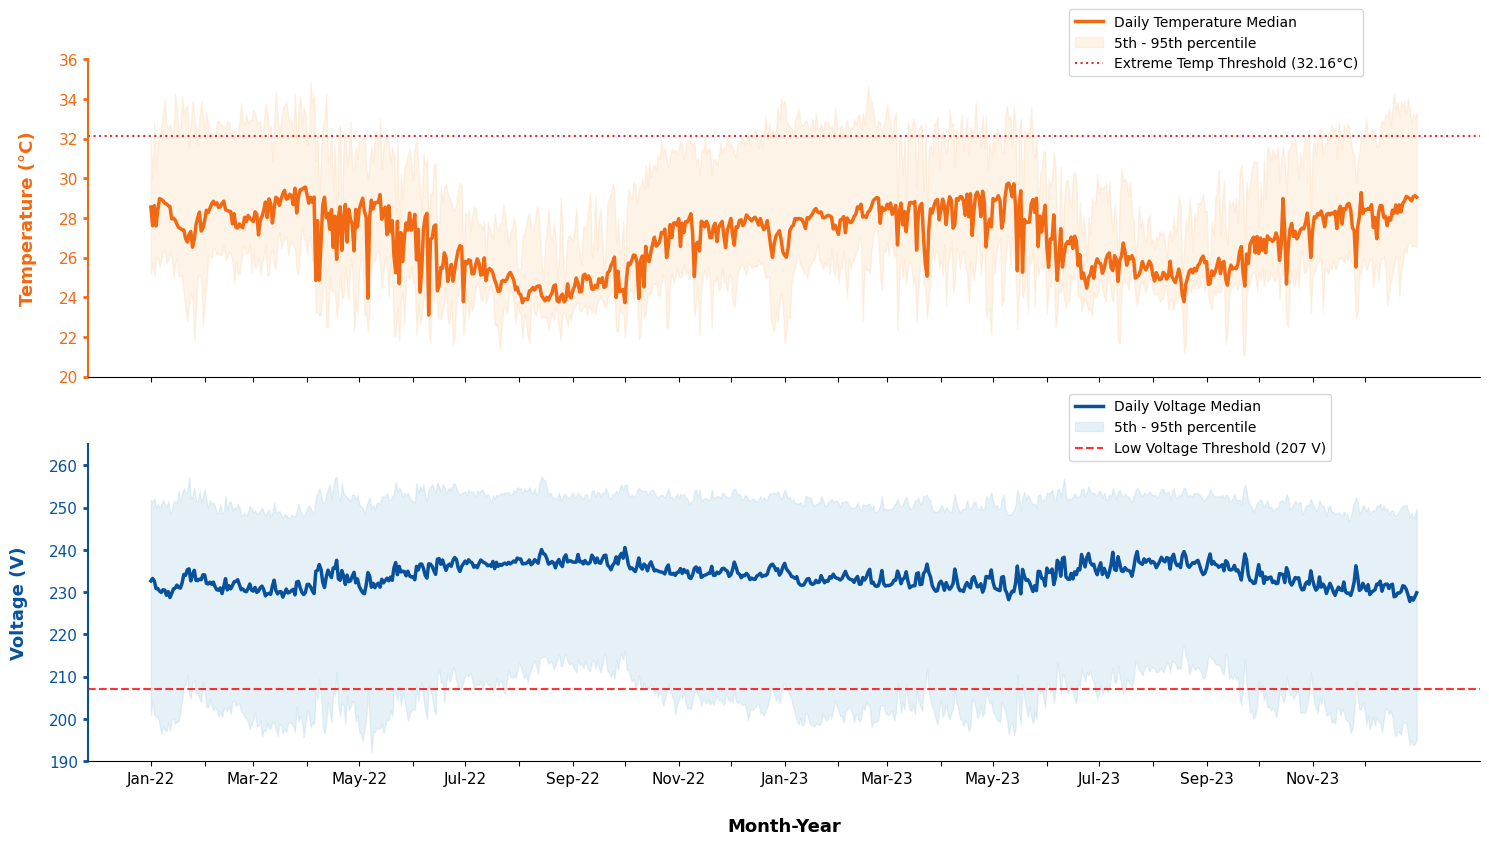

In [16]:
daily_voltage_summary, daily_temp_summary = plot_daily_voltage_temp_stacked_monthly(
    combined_hourly_voltage_df,
    figsize=(15, 8),
    temp_threshold=32.16,
    temp_threshold_color='#d7191c',
    temp_threshold_linestyle=':',
    temp_threshold_label='Extreme Temp Threshold (32.16°C)',
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    voltage_ylim=(190, 265),
    temp_ylim=(20, 36),
    legend_loc='upper left',
    legend_bbox=(0.7, 1.18),
    show_every_n_months=2,   # Jan-22, Mar-22, May-22 ...
    rotate_xticks=0, 
    # save_path = PLOTS_DIR / 'hourly_temp_n_volt_v1.png'
)

### Resampling by -> `rolling windows` 

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_resampled_voltage_temp_stacked(
    df,
    start_time=None,
    end_time=None,
    site_ids=None,
    cesi_level=None,

    voltage_col='voltage',
    temp_col='Temp',

    resample_rule='D',

    center='median',
    lower_q=0.10,
    upper_q=0.90,

    ignore_zero=True,

    figsize=(15, 8),

    voltage_line_color='#08519c',
    voltage_band_color='#9ecae1',

    temp_line_color='#f16913',
    temp_band_color='#fdd0a2',

    linewidth=2.5,
    alpha_band=0.25,

    voltage_ylabel='Voltage (V)',
    temp_ylabel='Temperature (°C)',
    xlabel='Time',

    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,

    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.5,

    show_temp_threshold=True,
    temp_threshold=32,
    temp_threshold_color='darkred',
    temp_threshold_linestyle='--',
    temp_threshold_linewidth=1.5,
    temp_threshold_label='WHO Thermal Comfort Threshold (32°C)',

    voltage_ylim=None,
    temp_ylim=None,

    legend_loc='upper left',
    legend_bbox=None,

    sharex=True
):

    plot_df = df.copy()

    plot_df['time'] = pd.to_datetime(
        plot_df['time']
    )

    # -------------------------
    # Filtering
    # -------------------------
    if site_ids is not None:

        plot_df = plot_df[
            plot_df['site_id'].isin(site_ids)
        ]

    if cesi_level is not None:

        plot_df = plot_df[
            plot_df['cesi_level'] == cesi_level
        ]

    if start_time is not None:

        plot_df = plot_df[
            plot_df['time'] >= pd.to_datetime(start_time)
        ]

    if end_time is not None:

        plot_df = plot_df[
            plot_df['time'] <= pd.to_datetime(end_time)
        ]

    if ignore_zero:

        plot_df = plot_df[
            plot_df[voltage_col] != 0
        ]

    plot_df = plot_df.dropna(subset=['time'])

    # -------------------------
    # Resampling setup
    # -------------------------
    plot_df = plot_df.sort_values('time')

    plot_df = plot_df.set_index('time')

    # -------------------------
    # Validate center
    # -------------------------
    if center not in ['mean', 'median']:

        raise ValueError(
            "center must be either 'mean' or 'median'"
        )

    percentile_label = (
        f'{int(lower_q * 100)}th - '
        f'{int(upper_q * 100)}th percentile'
    )

    # -------------------------
    # Resampled voltage summaries
    # -------------------------
    voltage_grouped = (
        plot_df
        .dropna(subset=[voltage_col])
        .resample(resample_rule)[voltage_col]
        .agg(
            voltage_center=center,
            voltage_lower=lambda x: x.quantile(lower_q),
            voltage_upper=lambda x: x.quantile(upper_q),
            voltage_n='count'
        )
        .reset_index()
    )

    # -------------------------
    # Resampled temperature summaries
    # -------------------------
    temp_grouped = (
        plot_df
        .dropna(subset=[temp_col])
        .resample(resample_rule)[temp_col]
        .agg(
            temp_center=center,
            temp_lower=lambda x: x.quantile(lower_q),
            temp_upper=lambda x: x.quantile(upper_q),
            temp_n='count'
        )
        .reset_index()
    )

    # -------------------------
    # Figure
    # -------------------------
    fig, axes = plt.subplots(
        2,
        1,
        figsize=figsize,
        sharex=sharex
    )

    ax_temp = axes[0]
    ax_volt = axes[1]

    # =================================================
    # TEMPERATURE SUBPLOT
    # =================================================

    ax_temp.fill_between(
        temp_grouped['time'],
        temp_grouped['temp_lower'],
        temp_grouped['temp_upper'],
        color=temp_band_color,
        alpha=alpha_band,
        label=percentile_label
    )

    ax_temp.plot(
        temp_grouped['time'],
        temp_grouped['temp_center'],
        color=temp_line_color,
        linewidth=linewidth,
        label=f'{resample_rule} Temperature {center.capitalize()}'
    )

    if show_temp_threshold:

        ax_temp.axhline(
            temp_threshold,
            color=temp_threshold_color,
            linestyle=temp_threshold_linestyle,
            linewidth=temp_threshold_linewidth,
            alpha=0.9,
            label=temp_threshold_label
        )

    ax_temp.set_ylabel(
        temp_ylabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15,
        color=temp_line_color
    )

    ax_temp.tick_params(
        axis='y',
        colors=temp_line_color,
        labelsize=11,
        width=2
    )

    ax_temp.tick_params(
        axis='x',
        labelsize=11
    )

    ax_temp.spines['left'].set_color(
        temp_line_color
    )

    ax_temp.spines['left'].set_linewidth(1.5)

    if temp_ylim is not None:

        ax_temp.set_ylim(temp_ylim)

    # Temperature legend order
    temp_handles, temp_labels = (
        ax_temp.get_legend_handles_labels()
    )

    temp_order = [
        temp_labels.index(
            f'{resample_rule} Temperature {center.capitalize()}'
        ),
        temp_labels.index(percentile_label)
    ]

    if show_temp_threshold:

        temp_order.append(
            temp_labels.index(temp_threshold_label)
        )

    ax_temp.legend(
        [temp_handles[i] for i in temp_order],
        [temp_labels[i] for i in temp_order],
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    # =================================================
    # VOLTAGE SUBPLOT
    # =================================================

    ax_volt.fill_between(
        voltage_grouped['time'],
        voltage_grouped['voltage_lower'],
        voltage_grouped['voltage_upper'],
        color=voltage_band_color,
        alpha=alpha_band,
        label=percentile_label
    )

    ax_volt.plot(
        voltage_grouped['time'],
        voltage_grouped['voltage_center'],
        color=voltage_line_color,
        linewidth=linewidth,
        label=f'{resample_rule} Voltage {center.capitalize()}'
    )

    if show_voltage_bounds:

        lower_bound = (
            nominal_voltage * (1 - tolerance)
        )

        upper_bound = (
            nominal_voltage * (1 + tolerance)
        )

        ax_volt.axhline(
            lower_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label='Lower Voltage Bound'
        )

        ax_volt.axhline(
            upper_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label='Upper Voltage Bound'
        )

    ax_volt.set_xlabel(
        xlabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15
    )

    ax_volt.set_ylabel(
        voltage_ylabel,
        fontsize=13,
        fontweight='bold',
        labelpad=15,
        color=voltage_line_color
    )

    ax_volt.tick_params(
        axis='y',
        colors=voltage_line_color,
        labelsize=11,
        width=2
    )

    ax_volt.tick_params(
        axis='x',
        labelsize=11
    )

    ax_volt.spines['left'].set_color(
        voltage_line_color
    )

    ax_volt.spines['left'].set_linewidth(1.5)

    if voltage_ylim is not None:

        ax_volt.set_ylim(voltage_ylim)

    # Voltage legend order
    volt_handles, volt_labels = (
        ax_volt.get_legend_handles_labels()
    )

    volt_order = [
        volt_labels.index(
            f'{resample_rule} Voltage {center.capitalize()}'
        ),
        volt_labels.index(percentile_label)
    ]

    if show_voltage_bounds:

        volt_order.extend([
            volt_labels.index('Lower Voltage Bound'),
            volt_labels.index('Upper Voltage Bound')
        ])

    ax_volt.legend(
        [volt_handles[i] for i in volt_order],
        [volt_labels[i] for i in volt_order],
        loc=legend_loc,
        bbox_to_anchor=legend_bbox
    )

    # -------------------------
    # Clean styling
    # -------------------------
    for ax in axes:

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    if cesi_level is not None:

        fig.suptitle(
            f'{cesi_level} CESI',
            fontsize=15,
            fontweight='bold',
            y=1.02
        )

    plt.tight_layout()
    plt.show()

    return voltage_grouped, temp_grouped

In [18]:
# daily_voltage_summary, daily_temp_summary = plot_resampled_voltage_temp_stacked(
#     combined_hourly_voltage_df,
#     figsize=(15, 8),
#     resample_rule='1D',
#     center='median',
#     lower_q=0.05,
#     upper_q=0.95,
#     voltage_ylim=(190, 265),
#     temp_ylim=(20, 36), 
#     legend_loc='upper left',
#     legend_bbox=(1,1),
# )

## *** Hour of the day 

### Hourly summary (w/ percentiles) - `All Hours` 

### optional: overlay with temp 

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_voltage_by_hour_of_day(
    df,
    site_ids=None,
    cesi_level=None,

    center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,

    figsize=(12, 6),

    linewidth=2.5,
    alpha_band=0.25,

    voltage_line_color='#08519c',
    voltage_band_color='#9ecae1',

    ylabel='Voltage (V)',

    plot_temp=False,
    temp_center='median',
    temp_linewidth=2.5,
    temp_line_color='#f16913',
    temp_ylabel='Temperature (°C)',

    xlabel='Hour of Day',

    legend_loc='best',
    legend_bbox=None,

    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,

    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.5,

    ylim=None,
    temp_ylim=None
):

    # =================================================
    # Copy + prep
    # =================================================
    plot_df = df.copy()

    plot_df['time'] = pd.to_datetime(
        plot_df['time']
    )

    # =================================================
    # Filter sites
    # =================================================
    if site_ids is not None:

        plot_df = plot_df[
            plot_df['site_id'].isin(site_ids)
        ]

    # =================================================
    # Filter CESI
    # =================================================
    if cesi_level is not None:

        plot_df = plot_df[
            plot_df['cesi_level'] == cesi_level
        ]

    # =================================================
    # Remove zero voltages
    # =================================================
    if ignore_zero:

        plot_df = plot_df[
            plot_df['voltage'] != 0
        ]

    plot_df = plot_df.dropna(
        subset=['time']
    )

    # =================================================
    # Hour of day
    # =================================================
    plot_df['hour'] = (
        plot_df['time']
        .dt.hour
    )

    # =================================================
    # Validate aggregation choices
    # =================================================
    if center not in ['mean', 'median']:

        raise ValueError(
            "center must be either "
            "'mean' or 'median'"
        )

    if temp_center not in ['mean', 'median']:

        raise ValueError(
            "temp_center must be either "
            "'mean' or 'median'"
        )

    # =================================================
    # Voltage aggregation
    # =================================================
    voltage_grouped = (

        plot_df
        .dropna(subset=['voltage'])

        .groupby('hour')['voltage']

        .agg(
            center_value=center,

            lower=lambda x:
                x.quantile(lower_q),

            upper=lambda x:
                x.quantile(upper_q),

            n='count'
        )

        .reset_index()

        .sort_values('hour')
    )

    # =================================================
    # Temperature aggregation
    # =================================================
    if plot_temp:

        temp_grouped = (

            plot_df
            .dropna(subset=['Temp'])

            .groupby('hour')['Temp']

            .agg(
                center_value=temp_center,
                n='count'
            )

            .reset_index()

            .sort_values('hour')
        )

    # =================================================
    # Figure
    # =================================================
    fig, ax = plt.subplots(
        figsize=figsize
    )

    # =================================================
    # Voltage percentile band
    # =================================================
    ax.fill_between(

        voltage_grouped['hour'],

        voltage_grouped['lower'],
        voltage_grouped['upper'],

        color=voltage_band_color,

        alpha=alpha_band,

        label=(
            f'Voltage '
            f'{int(lower_q*100)}th–'
            f'{int(upper_q*100)}th percentile'
        )
    )

    # =================================================
    # Voltage median/mean line
    # =================================================
    ax.plot(

        voltage_grouped['hour'],

        voltage_grouped['center_value'],

        color=voltage_line_color,

        linewidth=linewidth,

        marker='o',

        label=(
            f'Voltage '
            f'{center.capitalize()}'
        )
    )

    # =================================================
    # Voltage bounds
    # =================================================
    if show_voltage_bounds:

        lower_bound = (
            nominal_voltage *
            (1 - tolerance)
        )

        upper_bound = (
            nominal_voltage *
            (1 + tolerance)
        )

        ax.axhline(
            lower_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label=(
                f'Lower Voltage Bound '
                f'({lower_bound:.0f} V)'
            )
        )

        ax.axhline(
            upper_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label=(
                f'Upper Voltage Bound '
                f'({upper_bound:.0f} V)'
            )
        )

    # =================================================
    # Temperature plotting
    # =================================================
    if plot_temp:

        ax2 = ax.twinx()

        ax2.plot(

            temp_grouped['hour'],

            temp_grouped['center_value'],

            color=temp_line_color,

            linewidth=temp_linewidth,

            marker='s',

            label=(
                f'Temperature '
                f'{temp_center.capitalize()}'
            )
        )

        ax2.set_ylabel(

            temp_ylabel,

            fontsize=16,
            fontweight='bold',

            labelpad=15,

            color=temp_line_color
        )

        if temp_ylim is not None:

            ax2.set_ylim(
                temp_ylim
            )

    # =================================================
    # Labels
    # =================================================
    ax.set_xlabel(

        xlabel,

        fontsize=16,
        fontweight='bold',

        labelpad=15
    )

    ax.set_ylabel(

        ylabel,

        fontsize=16,
        fontweight='bold',

        labelpad=15,

        color=voltage_line_color
    )

    # =================================================
    # X ticks
    # =================================================
    ax.set_xticks(
        range(24)
    )

    ax.tick_params(
        axis='x',
        labelsize=11,
        width=1.5
    )

    # =================================================
    # Voltage axis styling
    # =================================================
    ax.spines["left"].set_color(
        voltage_line_color
    )

    ax.spines["left"].set_linewidth(1.5)

    ax.tick_params(
        axis="y",
        colors=voltage_line_color,
        labelsize=11,
        width=2
    )

    # =================================================
    # Temperature axis styling
    # =================================================
    if plot_temp:

        ax2.spines["right"].set_color(
            temp_line_color
        )

        ax2.spines["right"].set_linewidth(1.5)

        ax2.tick_params(
            axis="y",
            colors=temp_line_color,
            labelsize=11,
            width=2
        )

        ax2.spines["left"].set_visible(False)

        ax2.spines["top"].set_visible(False)

    # =================================================
    # Hide extra spines
    # =================================================
    ax.spines["top"].set_visible(False)

    if plot_temp:
        ax.spines["right"].set_visible(False)

    # =================================================
    # Optional y-limits
    # =================================================
    if ylim is not None:

        ax.set_ylim(
            ylim
        )

    # =================================================
    # Legend
    # =================================================
    handles1, labels1 = (
        ax.get_legend_handles_labels()
    )

    if plot_temp:

        handles2, labels2 = (
            ax2.get_legend_handles_labels()
        )

        ax.legend(

            handles1 + handles2,

            labels1 + labels2,

            loc=legend_loc,

            bbox_to_anchor=legend_bbox
        )

    else:

        ax.legend(
            loc=legend_loc,
            bbox_to_anchor=legend_bbox
        )

    # =================================================
    # Title
    # =================================================
    if cesi_level is not None:

        ax.set_title(
            f'{cesi_level} CESI',
            fontsize=14,
            fontweight='bold'
        )

    plt.tight_layout()

    plt.show()

    # =================================================
    # Return
    # =================================================
    if plot_temp:

        return (
            voltage_grouped,
            temp_grouped
        )

    return voltage_grouped

In [20]:
# summary_all_hour = plot_voltage_by_hour_of_day(
#     combined_hourly_voltage_df,
#     cesi_level = None,
#     center='median',
#     lower_q=0.05,
#     upper_q=0.95,
#     # ylim=(180, 260), 
#     plot_temp=True,
#     legend_loc='upper left',
#     legend_bbox=(1.05, 1), 
#     figsize=(16, 8)
# )

### Vertical Orientation 

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_voltage_temp_hour_of_day_stacked(
    df,
    site_ids=None,
    cesi_level=None,

    center='median',
    temp_center='median',
    lower_q=0.25,
    upper_q=0.75,
    ignore_zero=True,

    figsize=(12, 9),
    height_ratios=(1, 1.2),

    voltage_line_color='#08519c',
    voltage_band_color='#9ecae1',
    temp_line_color='#f16913',
    temp_band_color='#fdd0a2',

    linewidth=2.5,
    temp_linewidth=2.5,
    alpha_band=0.25,
    temp_alpha_band=0.25,

    voltage_ylabel='Voltage (V)',
    temp_ylabel='Temperature (°C)',
    xlabel='Hour of Day',

    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,
    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.5,

    ylim=None,
    temp_ylim=None,

    legend_loc='best',
    legend_bbox=None,

    temp_legend_loc='best',
    temp_legend_bbox=None,

    save_path=None,
    dpi=300
):

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    if site_ids is not None:
        plot_df = plot_df[
            plot_df['site_id'].isin(site_ids)
        ]

    if cesi_level is not None:
        plot_df = plot_df[
            plot_df['cesi_level'] == cesi_level
        ]

    if ignore_zero:
        plot_df = plot_df[
            plot_df['voltage'] != 0
        ]

    plot_df = plot_df.dropna(subset=['time'])
    plot_df['hour'] = plot_df['time'].dt.hour

    if center not in ['mean', 'median']:
        raise ValueError("center must be either 'mean' or 'median'")

    if temp_center not in ['mean', 'median']:
        raise ValueError("temp_center must be either 'mean' or 'median'")

    voltage_grouped = (
        plot_df
        .dropna(subset=['voltage'])
        .groupby('hour')['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count'
        )
        .reset_index()
        .sort_values('hour')
    )

    temp_grouped = (
        plot_df
        .dropna(subset=['Temp'])
        .groupby('hour')['Temp']
        .agg(
            center_value=temp_center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count'
        )
        .reset_index()
        .sort_values('hour')
    )

    fig, (ax_temp, ax_volt) = plt.subplots(
        2,
        1,
        figsize=figsize,
        sharex=True,
        gridspec_kw={'height_ratios': height_ratios}
    )

    # =================================================
    # TEMPERATURE PLOT — TOP
    # =================================================
    ax_temp.fill_between(
        temp_grouped['hour'],
        temp_grouped['lower'],
        temp_grouped['upper'],
        color=temp_band_color,
        alpha=temp_alpha_band,
        label=f'Temperature {int(lower_q*100)}th–{int(upper_q*100)}th percentile'
    )

    ax_temp.plot(
        temp_grouped['hour'],
        temp_grouped['center_value'],
        color=temp_line_color,
        linewidth=temp_linewidth,
        marker='s',
        label=f'Temperature {temp_center.capitalize()}'
    )

    ax_temp.set_ylabel(
        temp_ylabel,
        fontsize=16,
        fontweight='bold',
        labelpad=15,
        color=temp_line_color
    )

    ax_temp.spines['left'].set_color(temp_line_color)
    ax_temp.spines['left'].set_linewidth(1.5)

    ax_temp.tick_params(
        axis='y',
        colors=temp_line_color,
        labelsize=11,
        width=2
    )

    ax_temp.tick_params(
        axis='x',
        labelsize=11,
        width=1.5
    )

    ax_temp.spines['top'].set_visible(False)
    ax_temp.spines['right'].set_visible(False)

    if temp_ylim is not None:
        ax_temp.set_ylim(temp_ylim)

    ax_temp.legend(
        loc=temp_legend_loc,
        bbox_to_anchor=temp_legend_bbox,
        fontsize=11
    )

    # =================================================
    # VOLTAGE PLOT — BOTTOM
    # =================================================
    ax_volt.fill_between(
        voltage_grouped['hour'],
        voltage_grouped['lower'],
        voltage_grouped['upper'],
        color=voltage_band_color,
        alpha=alpha_band,
        label=f'Voltage {int(lower_q*100)}th–{int(upper_q*100)}th percentile'
    )

    ax_volt.plot(
        voltage_grouped['hour'],
        voltage_grouped['center_value'],
        color=voltage_line_color,
        linewidth=linewidth,
        marker='o',
        label=f'Voltage {center.capitalize()}'
    )

    if show_voltage_bounds:

        lower_bound = nominal_voltage * (1 - tolerance)
        upper_bound = nominal_voltage * (1 + tolerance)

        ax_volt.axhline(
            lower_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label=f'Lower Voltage Bound ({lower_bound:.0f} V)'
        )

        ax_volt.axhline(
            upper_bound,
            color=bounds_color,
            linestyle=bounds_linestyle,
            linewidth=bounds_linewidth,
            alpha=0.8,
            label=f'Upper Voltage Bound ({upper_bound:.0f} V)'
        )

    ax_volt.set_xlabel(
        xlabel,
        fontsize=16,
        fontweight='bold',
        labelpad=15
    )

    ax_volt.set_ylabel(
        voltage_ylabel,
        fontsize=16,
        fontweight='bold',
        labelpad=15,
        color=voltage_line_color
    )

    ax_volt.spines['left'].set_color(voltage_line_color)
    ax_volt.spines['left'].set_linewidth(1.5)

    ax_volt.tick_params(
        axis='y',
        colors=voltage_line_color,
        labelsize=11,
        width=2
    )

    ax_volt.tick_params(
        axis='x',
        labelsize=11,
        width=1.5
    )

    ax_volt.spines['top'].set_visible(False)
    ax_volt.spines['right'].set_visible(False)

    ax_volt.set_xticks(range(24))

    if ylim is not None:
        ax_volt.set_ylim(ylim)

    ax_volt.legend(
        loc=legend_loc,
        bbox_to_anchor=legend_bbox,
        fontsize=11
    )

    if cesi_level is not None:
        fig.suptitle(
            f'{cesi_level} CESI',
            fontsize=16,
            fontweight='bold',
            y=1.02
        )

    plt.tight_layout()

    if save_path:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight'
        )

    plt.show()

    return voltage_grouped, temp_grouped

In [22]:
# voltage_hourly, temp_hourly = plot_voltage_temp_hour_of_day_stacked(
#     combined_hourly_voltage_df,
#     cesi_level=None, 
#     lower_q=0.05,
#     upper_q=0.95,
#     figsize=(14, 10), 
#     legend_loc = 'upper left',
#     legend_bbox = (1, 1), 

#     temp_legend_loc = 'upper left',
#     temp_legend_bbox = (1, 1),
# )

### Hour of day plots (`by Quarter`) 

### Optional: overlay temp 

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches


def plot_quarterly_hour_of_day_profiles(
    df,
    site_ids=None,
    cesi_level=None,

    show_temperature=True,

    center='median',
    temp_center='median',

    lower_q=0.25,
    upper_q=0.75,

    ignore_zero=True,

    figsize=(14, 8),
    ncols=2,

    linewidth=2.5,
    temp_linewidth=2.5,
    alpha_band=0.25,

    voltage_line_color='#08519c',
    voltage_band_color='#9ecae1',
    temp_line_color='#f16913',

    ylabel='Voltage (V)',
    temp_ylabel='Temperature (°C)',
    xlabel='Hour of Day',

    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,

    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.2,

    sharey=True,
    ylim=None,
    temp_ylim=None,

    # NEW
    quarter_label_map=None,

    legend_loc='upper center',
    legend_bbox=(0.5, 1.03),
    legend_ncol=5,
    legend_fontsize=11,
    legend_frameon=False,

    save_path=None,
    dpi=300
):

    plot_df = df.copy()

    plot_df['time'] = pd.to_datetime(plot_df['time'])

    if site_ids is not None:
        plot_df = plot_df[
            plot_df['site_id'].isin(site_ids)
        ]

    if cesi_level is not None:
        plot_df = plot_df[
            plot_df['cesi_level'] == cesi_level
        ]

    if ignore_zero:
        plot_df = plot_df[
            plot_df['voltage'] != 0
        ]

    plot_df = plot_df.dropna(subset=['time'])

    plot_df['hour'] = plot_df['time'].dt.hour
    plot_df['quarter'] = plot_df['time'].dt.quarter

    # -------------------------------------------------
    # Quarter labels
    # -------------------------------------------------
    if quarter_label_map is None:

        quarter_label_map = {
            1: 'Jan–Mar',
            2: 'Apr–Jun',
            3: 'Jul–Sep',
            4: 'Oct–Dec'
        }

    plot_df['quarter_label'] = (
        plot_df['quarter']
        .map(quarter_label_map)
    )

    if center not in ['mean', 'median']:
        raise ValueError(
            "center must be either 'mean' or 'median'"
        )

    if temp_center not in ['mean', 'median']:
        raise ValueError(
            "temp_center must be either 'mean' or 'median'"
        )

    # -------------------------------------------------
    # Voltage aggregation
    # -------------------------------------------------
    voltage_grouped = (
        plot_df
        .dropna(subset=['voltage'])
        .groupby(
            ['quarter', 'quarter_label', 'hour']
        )['voltage']
        .agg(
            center_value=center,
            lower=lambda x: x.quantile(lower_q),
            upper=lambda x: x.quantile(upper_q),
            n='count'
        )
        .reset_index()
        .sort_values(['quarter', 'hour'])
    )

    # -------------------------------------------------
    # Temperature aggregation
    # -------------------------------------------------
    if show_temperature:

        temp_grouped = (
            plot_df
            .dropna(subset=['Temp'])
            .groupby(
                ['quarter', 'quarter_label', 'hour']
            )['Temp']
            .agg(
                center_value=temp_center,
                n='count'
            )
            .reset_index()
            .sort_values(['quarter', 'hour'])
        )

    else:
        temp_grouped = None

    unique_quarters = (
        voltage_grouped[
            ['quarter', 'quarter_label']
        ]
        .drop_duplicates()
        .sort_values('quarter')
    )

    n_quarters = len(unique_quarters)

    nrows = int(
        np.ceil(n_quarters / ncols)
    )

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharey=sharey
    )

    axes = np.array(axes).flatten()

    lower_bound = nominal_voltage * (1 - tolerance)
    upper_bound = nominal_voltage * (1 + tolerance)

    ax2_list = []

    # =================================================
    # LOOP THROUGH QUARTERS
    # =================================================
    for i, (_, row) in enumerate(
        unique_quarters.iterrows()
    ):

        quarter_num = row['quarter']
        quarter_label = row['quarter_label']

        ax = axes[i]

        # ---------------------------------------------
        # Temperature twin axis
        # ---------------------------------------------
        if show_temperature:

            ax2 = ax.twinx()
            ax2_list.append(ax2)

        else:
            ax2 = None

        # ---------------------------------------------
        # Quarter data
        # ---------------------------------------------
        quarter_voltage_df = voltage_grouped[
            voltage_grouped['quarter'] == quarter_num
        ]

        # ---------------------------------------------
        # Voltage band
        # ---------------------------------------------
        ax.fill_between(
            quarter_voltage_df['hour'],
            quarter_voltage_df['lower'],
            quarter_voltage_df['upper'],
            color=voltage_band_color,
            alpha=alpha_band
        )

        # ---------------------------------------------
        # Voltage median/mean
        # ---------------------------------------------
        ax.plot(
            quarter_voltage_df['hour'],
            quarter_voltage_df['center_value'],
            color=voltage_line_color,
            linewidth=linewidth
        )

        # ---------------------------------------------
        # Voltage bounds
        # ---------------------------------------------
        if show_voltage_bounds:

            ax.axhline(
                lower_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

            ax.axhline(
                upper_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

        # ---------------------------------------------
        # Temperature plot
        # ---------------------------------------------
        if show_temperature:

            quarter_temp_df = temp_grouped[
                temp_grouped['quarter'] == quarter_num
            ]

            ax2.plot(
                quarter_temp_df['hour'],
                quarter_temp_df['center_value'],
                color=temp_line_color,
                linewidth=temp_linewidth,
                linestyle='-'
            )

        # ---------------------------------------------
        # Voltage axis styling
        # ---------------------------------------------
        ax.spines['left'].set_color(
            voltage_line_color
        )

        ax.spines['left'].set_linewidth(1.5)

        ax.tick_params(
            axis='y',
            colors=voltage_line_color,
            labelsize=10,
            width=2
        )

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # ---------------------------------------------
        # Temperature axis styling
        # ---------------------------------------------
        if show_temperature:

            ax2.spines['right'].set_color(
                temp_line_color
            )

            ax2.spines['right'].set_linewidth(1.5)

            ax2.tick_params(
                axis='y',
                colors=temp_line_color,
                labelsize=10,
                width=2
            )

            ax2.spines['top'].set_visible(False)
            ax2.spines['left'].set_visible(False)

        # ---------------------------------------------
        # Y limits
        # ---------------------------------------------
        if ylim is not None:
            ax.set_ylim(ylim)

        if (
            show_temperature
            and temp_ylim is not None
        ):
            ax2.set_ylim(temp_ylim)

        # ---------------------------------------------
        # Hide inner temperature ticks
        # ---------------------------------------------
        if show_temperature:

            col_index = i % ncols

            last_quarter_index = n_quarters - 1

            is_rightmost = (
                (col_index == ncols - 1)
                or
                (i == last_quarter_index)
            )

            if not is_rightmost:

                ax2.set_yticklabels([])

                ax2.tick_params(
                    axis='y',
                    length=0
                )

                ax2.spines['right'].set_visible(False)

        # ---------------------------------------------
        # Titles
        # ---------------------------------------------
        ax.set_title(
            quarter_label,
            fontsize=14,
            fontweight='bold'
        )

        # ---------------------------------------------
        # X axis
        # ---------------------------------------------
        ax.set_xticks(
            range(0, 24, 4)
        )

        ax.tick_params(
            axis='x',
            labelsize=10,
            width=1.5
        )

    # =================================================
    # REMOVE UNUSED AXES
    # =================================================
    for j in range(i + 1, len(axes)):

        fig.delaxes(axes[j])

    # =================================================
    # SYNC TEMP Y-LIMS
    # =================================================
    if (
        show_temperature
        and temp_ylim is None
        and len(ax2_list) > 0
    ):

        all_temp_mins = [
            ax2.get_ylim()[0]
            for ax2 in ax2_list
        ]

        all_temp_maxs = [
            ax2.get_ylim()[1]
            for ax2 in ax2_list
        ]

        unified_temp_ylim = (
            min(all_temp_mins),
            max(all_temp_maxs)
        )

        for ax2 in ax2_list:

            ax2.set_ylim(
                unified_temp_ylim
            )

    # =================================================
    # GLOBAL LABELS
    # =================================================
    fig.supxlabel(
        xlabel,
        fontsize=14,
        fontweight='bold',
        y=-0.02
    )

    fig.supylabel(
        ylabel,
        fontsize=14,
        fontweight='bold',
        x=-0.02,
        color=voltage_line_color
    )

    if show_temperature:

        fig.text(
            1.02,
            0.5,
            temp_ylabel,
            va='center',
            rotation='vertical',
            fontsize=14,
            fontweight='bold',
            color=temp_line_color
        )

    # =================================================
    # LEGEND
    # =================================================
    legend_handles = []

    if show_temperature:

        legend_handles.append(

            mlines.Line2D(
                [],
                [],
                color=temp_line_color,
                linewidth=temp_linewidth,
                label=(
                    f'Temperature '
                    f'{temp_center.capitalize()}'
                )
            )
        )

    legend_handles.extend([

        mlines.Line2D(
            [],
            [],
            color=voltage_line_color,
            linewidth=linewidth,
            label=(
                f'Voltage '
                f'{center.capitalize()}'
            )
        ),

        mpatches.Patch(
            color=voltage_band_color,
            alpha=alpha_band,
            label=(
                f'Voltage '
                f'{int(lower_q * 100)}th–'
                f'{int(upper_q * 100)}th percentile'
            )
        )
    ])

    if show_voltage_bounds:

        legend_handles.extend([

            mlines.Line2D(
                [],
                [],
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                label='Lower Voltage Bound'
            ),

            mlines.Line2D(
                [],
                [],
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                label='Upper Voltage Bound'
            )
        ])

    fig.legend(
        handles=legend_handles,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox,
        ncol=legend_ncol,
        fontsize=legend_fontsize,
        frameon=legend_frameon
    )

    plt.tight_layout()

    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight'
        )

    plt.show()

    return voltage_grouped, temp_grouped

In [24]:
# quarterly_all = plot_quarterly_hour_of_day_profiles(
#     combined_hourly_voltage_df,
#     cesi_level = None,
#     center='median',
#     lower_q=0.05,
#     upper_q=0.95,
#     ylim=(190, 260),
#     temp_ylim=(24,33), 
#     show_temperature=False, 
#     legend_bbox=(0.5, 1.05)
# )

In [25]:
# quarterly_all = plot_quarterly_hour_of_day_profiles(
#     combined_hourly_voltage_df,
#     cesi_level = None,
#     center='median',
#     lower_q=0.05,
#     upper_q=0.95,
#     ylim=(190, 260),
#     temp_ylim=(24,33), 
#     show_temperature=True, 
#     legend_bbox=(0.5, 1.05)
# )

### Hour of day plots (`by Season`)  

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches


def plot_seasonal_hour_of_day_profiles(
    df,
    season_col='season_detailed',
    site_ids=None,
    cesi_level=None,

    center='median',
    temp_center='median',

    lower_q=0.25,
    upper_q=0.75,

    ignore_zero=True,

    figsize=(14, 8),
    ncols=2,

    linewidth=2.5,

    temp_linewidth=2.5,
    temp_linestyle='--',

    alpha_band=0.25,

    voltage_line_color='#08519c',
    voltage_band_color='#9ecae1',
    temp_line_color='#f16913',

    ylabel='Voltage (V)',
    temp_ylabel='Temperature (°C)',
    xlabel='Hour of Day',

    plot_temp=True,

    show_voltage_bounds=True,
    nominal_voltage=230,
    tolerance=0.10,

    bounds_color='red',
    bounds_linestyle='--',
    bounds_linewidth=1.2,

    sharey=True,
    share_temp_y=True,

    ylim=None,
    temp_ylim=None,

    season_order=None,
    season_label_map=None,

    legend_loc='upper center',
    legend_bbox=(0.5, 1.03),
    legend_ncol=5,
    legend_fontsize=11,
    legend_frameon=False,

    save_path=None,
    dpi=300
):

    plot_df = df.copy()

    plot_df['time'] = pd.to_datetime(
        plot_df['time']
    )

    # =================================================
    # FILTERING
    # =================================================
    if site_ids is not None:

        plot_df = plot_df[
            plot_df['site_id'].isin(site_ids)
        ]

    if cesi_level is not None:

        plot_df = plot_df[
            plot_df['cesi_level'] == cesi_level
        ]

    if ignore_zero:

        plot_df = plot_df[
            plot_df['voltage'] != 0
        ]

    plot_df = plot_df.dropna(
        subset=['time', season_col]
    )

    # =================================================
    # VALIDATION
    # =================================================
    if center not in ['mean', 'median']:

        raise ValueError(
            "center must be either 'mean' or 'median'"
        )

    if temp_center not in ['mean', 'median']:

        raise ValueError(
            "temp_center must be either 'mean' or 'median'"
        )

    plot_df['hour'] = (
        plot_df['time']
        .dt.hour
    )

    # =================================================
    # DEFAULT SEASON ORDER
    # =================================================
    if season_order is None:

        if season_col == 'season_detailed':

            season_order = [
                'Dry_Season',
                'Major_Rainy_Season',
                'Minor_Rainy_Season',
                'Transition_Season'
            ]

        else:

            season_order = [
                'Dry_Season',
                'Rainy_Season',
                'Transition_Season'
            ]

    # =================================================
    # SEASON LABELS
    # =================================================
    if season_label_map is None:

        season_label_map = {
            'Dry_Season': 'Dry Season',
            'Major_Rainy_Season': 'Major Rainy Season',
            'Minor_Rainy_Season': 'Minor Rainy Season',
            'Transition_Season': 'Transition Season',
            'Rainy_Season': 'Rainy Season'
        }

    plot_df = plot_df[
        plot_df[season_col].isin(season_order)
    ]

    # =================================================
    # VOLTAGE AGGREGATION
    # =================================================
    voltage_grouped = (

        plot_df
        .dropna(subset=['voltage'])

        .groupby([season_col, 'hour'])['voltage']

        .agg(
            center_value=center,

            lower=lambda x: x.quantile(lower_q),

            upper=lambda x: x.quantile(upper_q),

            n='count'
        )

        .reset_index()
    )

    voltage_grouped[season_col] = pd.Categorical(
        voltage_grouped[season_col],
        categories=season_order,
        ordered=True
    )

    voltage_grouped = voltage_grouped.sort_values(
        [season_col, 'hour']
    )

    # =================================================
    # TEMP AGGREGATION
    # =================================================
    if plot_temp:

        temp_grouped = (

            plot_df
            .dropna(subset=['Temp'])

            .groupby([season_col, 'hour'])['Temp']

            .agg(
                center_value=temp_center,
                n='count'
            )

            .reset_index()
        )

        temp_grouped[season_col] = pd.Categorical(
            temp_grouped[season_col],
            categories=season_order,
            ordered=True
        )

        temp_grouped = temp_grouped.sort_values(
            [season_col, 'hour']
        )

    else:

        temp_grouped = None

    # =================================================
    # SEASONS PRESENT
    # =================================================
    seasons_present = [

        s for s in season_order

        if s in (
            voltage_grouped[season_col]
            .dropna()
            .astype(str)
            .unique()
        )
    ]

    n_seasons = len(seasons_present)

    nrows = int(np.ceil(n_seasons / ncols))

    # =================================================
    # SUBPLOTS
    # =================================================
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharey=sharey
    )

    axes = np.array(axes).flatten()

    lower_bound = nominal_voltage * (
        1 - tolerance
    )

    upper_bound = nominal_voltage * (
        1 + tolerance
    )

    temp_axes = []

    # =================================================
    # LOOP THROUGH SEASONS
    # =================================================
    for i, season in enumerate(seasons_present):

        ax = axes[i]

        col_idx = i % ncols

        # ---------------------------------------------
        # OUTER TEMP AXIS?
        # ---------------------------------------------
        is_outer_temp_axis = (
            col_idx == ncols - 1
        )

        # ---------------------------------------------
        # TEMP AXIS
        # ---------------------------------------------
        if plot_temp:

            ax2 = ax.twinx()

            temp_axes.append(ax2)

        else:

            ax2 = None

        # =================================================
        # VOLTAGE DATA
        # =================================================
        season_voltage_df = voltage_grouped[
            voltage_grouped[season_col] == season
        ]

        # ---------------------------------------------
        # VOLTAGE BAND
        # ---------------------------------------------
        ax.fill_between(
            season_voltage_df['hour'],
            season_voltage_df['lower'],
            season_voltage_df['upper'],
            color=voltage_band_color,
            alpha=alpha_band
        )

        # ---------------------------------------------
        # VOLTAGE LINE
        # ---------------------------------------------
        ax.plot(
            season_voltage_df['hour'],
            season_voltage_df['center_value'],
            color=voltage_line_color,
            linewidth=linewidth
        )

        # ---------------------------------------------
        # VOLTAGE BOUNDS
        # ---------------------------------------------
        if show_voltage_bounds:

            ax.axhline(
                lower_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

            ax.axhline(
                upper_bound,
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                alpha=0.8
            )

        # =================================================
        # TEMP DATA
        # =================================================
        if plot_temp:

            season_temp_df = temp_grouped[
                temp_grouped[season_col] == season
            ]

            ax2.plot(
                season_temp_df['hour'],
                season_temp_df['center_value'],
                color=temp_line_color,
                linewidth=temp_linewidth,
                linestyle=temp_linestyle
            )

        # =================================================
        # VOLTAGE AXIS STYLING
        # =================================================
        ax.spines['left'].set_color(
            voltage_line_color
        )

        ax.spines['left'].set_linewidth(1.5)

        ax.tick_params(
            axis='y',
            colors=voltage_line_color,
            labelsize=10,
            width=2
        )

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        # ---------------------------------------------
        # HIDE INNER VOLTAGE LABELS
        # ---------------------------------------------
        if sharey and col_idx != 0:

            ax.tick_params(
                axis='y',
                labelleft=False
            )

        # =================================================
        # TEMP AXIS STYLING
        # =================================================
        if plot_temp:

            ax2.spines['right'].set_color(
                temp_line_color
            )

            ax2.spines['right'].set_linewidth(1.5)

            ax2.tick_params(
                axis='y',
                colors=temp_line_color,
                labelsize=10,
                width=2
            )

            ax2.spines['top'].set_visible(False)
            ax2.spines['left'].set_visible(False)

            # -----------------------------------------
            # HIDE INNER TEMP AXES COMPLETELY
            # -----------------------------------------
            if share_temp_y and not is_outer_temp_axis:

                ax2.tick_params(
                    axis='y',
                    right=False,
                    labelright=False,
                    length=0
                )

                ax2.spines['right'].set_visible(False)

        # =================================================
        # LIMITS
        # =================================================
        if ylim is not None:

            ax.set_ylim(ylim)

        if plot_temp and temp_ylim is not None:

            ax2.set_ylim(temp_ylim)

        # =================================================
        # TITLES
        # =================================================
        ax.set_title(
            season_label_map.get(
                season,
                season
            ),
            fontsize=14,
            fontweight='bold'
        )

        # =================================================
        # X AXIS
        # =================================================
        ax.set_xticks(range(0, 24, 4))

        ax.tick_params(
            axis='x',
            labelsize=10,
            width=1.5
        )

    # =================================================
    # REMOVE UNUSED AXES
    # =================================================
    for j in range(i + 1, len(axes)):

        fig.delaxes(axes[j])

    # =================================================
    # SHARE TEMP Y LIMITS
    # =================================================
    if (
        plot_temp
        and share_temp_y
        and temp_ylim is None
        and len(temp_axes) > 1
    ):

        shared_temp_ylim = (

            min(
                ax2.get_ylim()[0]
                for ax2 in temp_axes
            ),

            max(
                ax2.get_ylim()[1]
                for ax2 in temp_axes
            )
        )

        for ax2 in temp_axes:

            ax2.set_ylim(shared_temp_ylim)

    # =================================================
    # GLOBAL LABELS
    # =================================================
    fig.supxlabel(
        xlabel,
        fontsize=14,
        fontweight='bold',
        y=-0.02
    )

    fig.supylabel(
        ylabel,
        fontsize=14,
        fontweight='bold',
        x=-0.02,
        color=voltage_line_color
    )

    if plot_temp:

        fig.text(
            1.02,
            0.5,
            temp_ylabel,
            va='center',
            rotation='vertical',
            fontsize=14,
            fontweight='bold',
            color=temp_line_color
        )

    # =================================================
    # LEGEND
    # =================================================
    legend_handles = []

    if plot_temp:

        legend_handles.append(

            mlines.Line2D(
                [],
                [],
                color=temp_line_color,
                linewidth=temp_linewidth,
                linestyle=temp_linestyle,
                label='Temperature Median'
            )
        )

    legend_handles.extend([

        mlines.Line2D(
            [],
            [],
            color=voltage_line_color,
            linewidth=linewidth,
            label='Voltage Median'
        ),

        mpatches.Patch(
            color=voltage_band_color,
            alpha=alpha_band,
            label=(
                f'Voltage '
                f'{int(lower_q * 100)}th–'
                f'{int(upper_q * 100)}th percentile'
            )
        )
    ])

    if show_voltage_bounds:

        legend_handles.extend([

            mlines.Line2D(
                [],
                [],
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                label='Lower Voltage Bound'
            ),

            mlines.Line2D(
                [],
                [],
                color=bounds_color,
                linestyle=bounds_linestyle,
                linewidth=bounds_linewidth,
                label='Upper Voltage Bound'
            )
        ])

    fig.legend(
        handles=legend_handles,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox,
        ncol=legend_ncol,
        fontsize=legend_fontsize,
        frameon=legend_frameon
    )

    plt.tight_layout()

    if save_path is not None:

        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight'
        )

    plt.show()

    if plot_temp:

        return voltage_grouped, temp_grouped

    return voltage_grouped

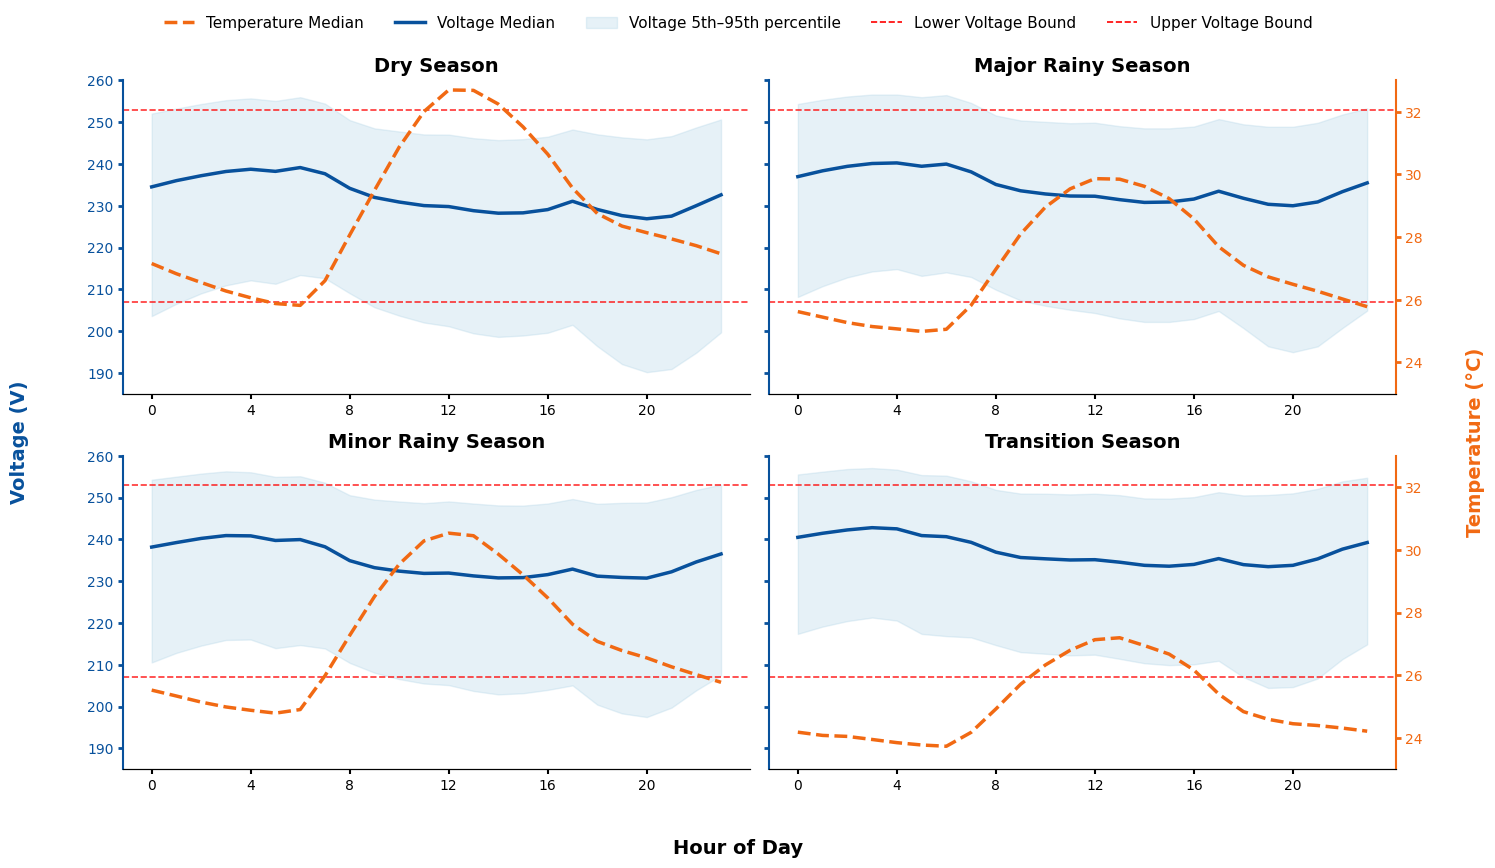

In [27]:
grouped_season = plot_seasonal_hour_of_day_profiles(
    combined_hourly_voltage_df,
    season_col='season_detailed',
    center='median',
    lower_q=0.05,
    upper_q=0.95,
    cesi_level=None, 
    plot_temp=True,
    temp_linewidth=2.5,
    temp_linestyle='--',
    ylim=(185, 260),
    temp_ylim=(23,33), 
    legend_bbox=(0.5, 1.05)
)

### Showing as boxplots 

In [28]:
def plot_seasonal_hourly_voltage_boxplots(
    df,
    season_col='season_detailed',
    site_ids=None,
    cesi_level=None,

    temp_center='median',
    ignore_zero=True,

    figsize=(14, 8),
    ncols=2,

    # Boxplot style
    box_color='#9ecae1',
    box_edge_color='#08519c',
    box_alpha=1.0,
    box_width=0.65,
    box_linewidth=1.2,

    whisker_color=None,
    whisker_linewidth=1.2,

    cap_color=None,
    cap_linewidth=1.2,

    median_color='#08519c',
    median_linewidth=2.0,

    showfliers=False,
    flier_marker='o',
    flier_marker_size=3,
    flier_marker_color='gray',
    flier_marker_alpha=0.5,

    # Temperature style
    temp_line_color='#f16913',
    temp_linewidth=2.5,
    temp_linestyle='--',

    ylabel='Voltage (V)',
    temp_ylabel='Temperature (°C)',
    xlabel='Hour of Day',

    plot_temp=True,

    show_voltage_bounds=True,
    show_lower_bound=None,
    show_upper_bound=None,
    nominal_voltage=230,
    tolerance=0.10,

    # Lower bound style
    lower_bound_color='red',
    lower_bound_linestyle='--',
    lower_bound_linewidth=1.2,

    # Upper bound style
    upper_bound_color='red',
    upper_bound_linestyle=':',
    upper_bound_linewidth=1.2,

    # Extreme temp threshold style
    show_extreme_temp=True,
    extreme_temp_value=32.16,
    extreme_temp_color='#d7191c',
    extreme_temp_linestyle=':',
    extreme_temp_linewidth=1.5,
    extreme_temp_label='Extreme Temp Threshold (32.16°C)',

    sharey=True,
    share_temp_y=True,

    ylim=None,
    temp_ylim=None,

    season_order=None,
    season_label_map=None,

    legend_loc='upper center',
    legend_bbox=(0.5, 1.05),
    legend_ncol=4,
    legend_fontsize=11,
    legend_frameon=False,

    save_path=None,
    dpi=300
):
    # Resolve per-bound flags from master toggle
    _show_lower = show_voltage_bounds if show_lower_bound is None else show_lower_bound
    _show_upper = show_voltage_bounds if show_upper_bound is None else show_upper_bound

    plot_df = df.copy()
    plot_df['time'] = pd.to_datetime(plot_df['time'])

    if site_ids is not None:
        plot_df = plot_df[plot_df['site_id'].isin(site_ids)]

    if cesi_level is not None:
        plot_df = plot_df[plot_df['cesi_level'] == cesi_level]

    if ignore_zero:
        plot_df = plot_df[plot_df['voltage'] != 0]

    plot_df = plot_df.dropna(subset=['time', season_col])
    plot_df['hour'] = plot_df['time'].dt.hour

    if temp_center not in ['mean', 'median']:
        raise ValueError("temp_center must be either 'mean' or 'median'")

    if season_order is None:
        if season_col == 'season_detailed':
            season_order = [
                'Dry_Season',
                'Major_Rainy_Season',
                'Minor_Rainy_Season',
                'Transition_Season'
            ]
        else:
            season_order = [
                'Dry_Season',
                'Rainy_Season',
                'Transition_Season'
            ]

    if season_label_map is None:
        season_label_map = {
            'Dry_Season': 'Dry Season',
            'Major_Rainy_Season': 'Major Rainy Season',
            'Minor_Rainy_Season': 'Minor Rainy Season',
            'Transition_Season': 'Transition Season',
            'Rainy_Season': 'Rainy Season'
        }

    plot_df = plot_df[plot_df[season_col].isin(season_order)]

    voltage_plot_df = plot_df.dropna(subset=['voltage']).copy()

    voltage_plot_df[season_col] = pd.Categorical(
        voltage_plot_df[season_col],
        categories=season_order,
        ordered=True
    )

    voltage_summary = (
        voltage_plot_df
        .groupby([season_col, 'hour'])['voltage']
        .agg(
            median='median',
            mean='mean',
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            n='count'
        )
        .reset_index()
    )

    if plot_temp:
        temp_grouped = (
            plot_df
            .dropna(subset=['Temp'])
            .groupby([season_col, 'hour'])['Temp']
            .agg(
                center_value=temp_center,
                n='count'
            )
            .reset_index()
        )

        temp_grouped[season_col] = pd.Categorical(
            temp_grouped[season_col],
            categories=season_order,
            ordered=True
        )

        temp_grouped = temp_grouped.sort_values([season_col, 'hour'])

    else:
        temp_grouped = None

    seasons_present = [
        s for s in season_order
        if s in voltage_plot_df[season_col].dropna().astype(str).unique()
    ]

    n_seasons = len(seasons_present)
    nrows = int(np.ceil(n_seasons / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=figsize,
        sharey=sharey
    )

    axes = np.array(axes).flatten()

    lower_bound = nominal_voltage * (1 - tolerance)
    upper_bound = nominal_voltage * (1 + tolerance)

    temp_axes = []

    if whisker_color is None:
        whisker_color = box_edge_color

    if cap_color is None:
        cap_color = box_edge_color

    for i, season in enumerate(seasons_present):

        ax = axes[i]
        col_idx = i % ncols

        season_voltage_df = voltage_plot_df[
            voltage_plot_df[season_col] == season
        ]

        sns.boxplot(
            data=season_voltage_df,
            x='hour',
            y='voltage',
            ax=ax,
            color=box_color,
            width=box_width,
            showfliers=showfliers,

            boxprops={
                'facecolor': box_color,
                'edgecolor': box_edge_color,
                'linewidth': box_linewidth,
                'alpha': box_alpha
            },

            whiskerprops={
                'color': whisker_color,
                'linewidth': whisker_linewidth
            },

            capprops={
                'color': cap_color,
                'linewidth': cap_linewidth
            },

            medianprops={
                'color': median_color,
                'linewidth': median_linewidth
            },

            flierprops={
                'marker': flier_marker,
                'markersize': flier_marker_size,
                'markerfacecolor': flier_marker_color,
                'markeredgecolor': flier_marker_color,
                'alpha': flier_marker_alpha
            }
        )

        if _show_lower:
            ax.axhline(
                lower_bound,
                color=lower_bound_color,
                linestyle=lower_bound_linestyle,
                linewidth=lower_bound_linewidth,
                alpha=0.8
            )

        if _show_upper:
            ax.axhline(
                upper_bound,
                color=upper_bound_color,
                linestyle=upper_bound_linestyle,
                linewidth=upper_bound_linewidth,
                alpha=0.8
            )

        if plot_temp:

            ax2 = ax.twinx()
            temp_axes.append(ax2)

            season_temp_df = temp_grouped[
                temp_grouped[season_col] == season
            ]

            ax2.plot(
                season_temp_df['hour'],
                season_temp_df['center_value'],
                color=temp_line_color,
                linewidth=temp_linewidth,
                linestyle=temp_linestyle
            )

            # Extreme temp threshold
            if show_extreme_temp:
                ax2.axhline(
                    extreme_temp_value,
                    color=extreme_temp_color,
                    linestyle=extreme_temp_linestyle,
                    linewidth=extreme_temp_linewidth,
                    alpha=0.85
                )

            ax2.spines['right'].set_color(temp_line_color)
            ax2.spines['right'].set_linewidth(1.5)

            ax2.tick_params(
                axis='y',
                colors=temp_line_color,
                labelsize=10,
                width=2
            )

            ax2.spines['top'].set_visible(False)
            ax2.spines['left'].set_visible(False)

            is_outer_temp_axis = col_idx == ncols - 1

            if share_temp_y and not is_outer_temp_axis:
                ax2.tick_params(
                    axis='y',
                    right=False,
                    labelright=False,
                    length=0
                )

                ax2.spines['right'].set_visible(False)

            if temp_ylim is not None:
                ax2.set_ylim(temp_ylim)

        ax.spines['left'].set_color(box_edge_color)
        ax.spines['left'].set_linewidth(1.5)

        ax.tick_params(
            axis='y',
            colors=box_edge_color,
            labelsize=10,
            width=2
        )

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        if sharey and col_idx != 0:
            ax.tick_params(axis='y', labelleft=False)

        if ylim is not None:
            ax.set_ylim(ylim)

        ax.set_title(
            season_label_map.get(season, season),
            fontsize=13,
            fontweight='normal'
        )

        ax.set_xlabel('')
        ax.set_ylabel('')

        ax.set_xticks(range(0, 24, 4))
        ax.set_xticklabels(range(0, 24, 4))

        ax.tick_params(
            axis='x',
            labelsize=10,
            width=1.5
        )

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    if (
        plot_temp
        and share_temp_y
        and temp_ylim is None
        and len(temp_axes) > 1
    ):
        shared_temp_ylim = (
            min(ax2.get_ylim()[0] for ax2 in temp_axes),
            max(ax2.get_ylim()[1] for ax2 in temp_axes)
        )

        for ax2 in temp_axes:
            ax2.set_ylim(shared_temp_ylim)

    fig.supxlabel(
        xlabel,
        fontsize=16,
        fontweight='bold',
        y=-0.01
    )

    fig.supylabel(
        ylabel,
        fontsize=16,
        fontweight='bold',
        x=-0.01,
        color=box_edge_color
    )

    if plot_temp:
        fig.text(
            1.02,
            0.5,
            temp_ylabel,
            va='center',
            rotation='vertical',
            fontsize=14,
            fontweight='bold',
            color=temp_line_color
        )

    legend_handles = [
        mpatches.Patch(
            facecolor=box_color,
            edgecolor=box_edge_color,
            alpha=box_alpha,
            label='Hourly Voltage Distribution'
        )
    ]

    if plot_temp:
        legend_handles.append(
            mlines.Line2D(
                [],
                [],
                color=temp_line_color,
                linewidth=temp_linewidth,
                linestyle=temp_linestyle,
                label='Temperature Median'
            )
        )

    if plot_temp and show_extreme_temp:
        legend_handles.append(
            mlines.Line2D(
                [],
                [],
                color=extreme_temp_color,
                linewidth=extreme_temp_linewidth,
                linestyle=extreme_temp_linestyle,
                label=extreme_temp_label
            )
        )

    if _show_lower:
        legend_handles.append(
            mlines.Line2D(
                [],
                [],
                color=lower_bound_color,
                linestyle=lower_bound_linestyle,
                linewidth=lower_bound_linewidth,
                label='Low Voltage Threshold'
            )
        )

    if _show_upper:
        legend_handles.append(
            mlines.Line2D(
                [],
                [],
                color=upper_bound_color,
                linestyle=upper_bound_linestyle,
                linewidth=upper_bound_linewidth,
                label='Upper Voltage Bound'
            )
        )

    fig.legend(
        handles=legend_handles,
        loc=legend_loc,
        bbox_to_anchor=legend_bbox,
        ncol=legend_ncol,
        fontsize=legend_fontsize,
        frameon=legend_frameon
    )

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(
            save_path,
            dpi=dpi,
            bbox_inches='tight'
        )

    plt.show()

    if plot_temp:
        return voltage_summary, temp_grouped

    return voltage_summary

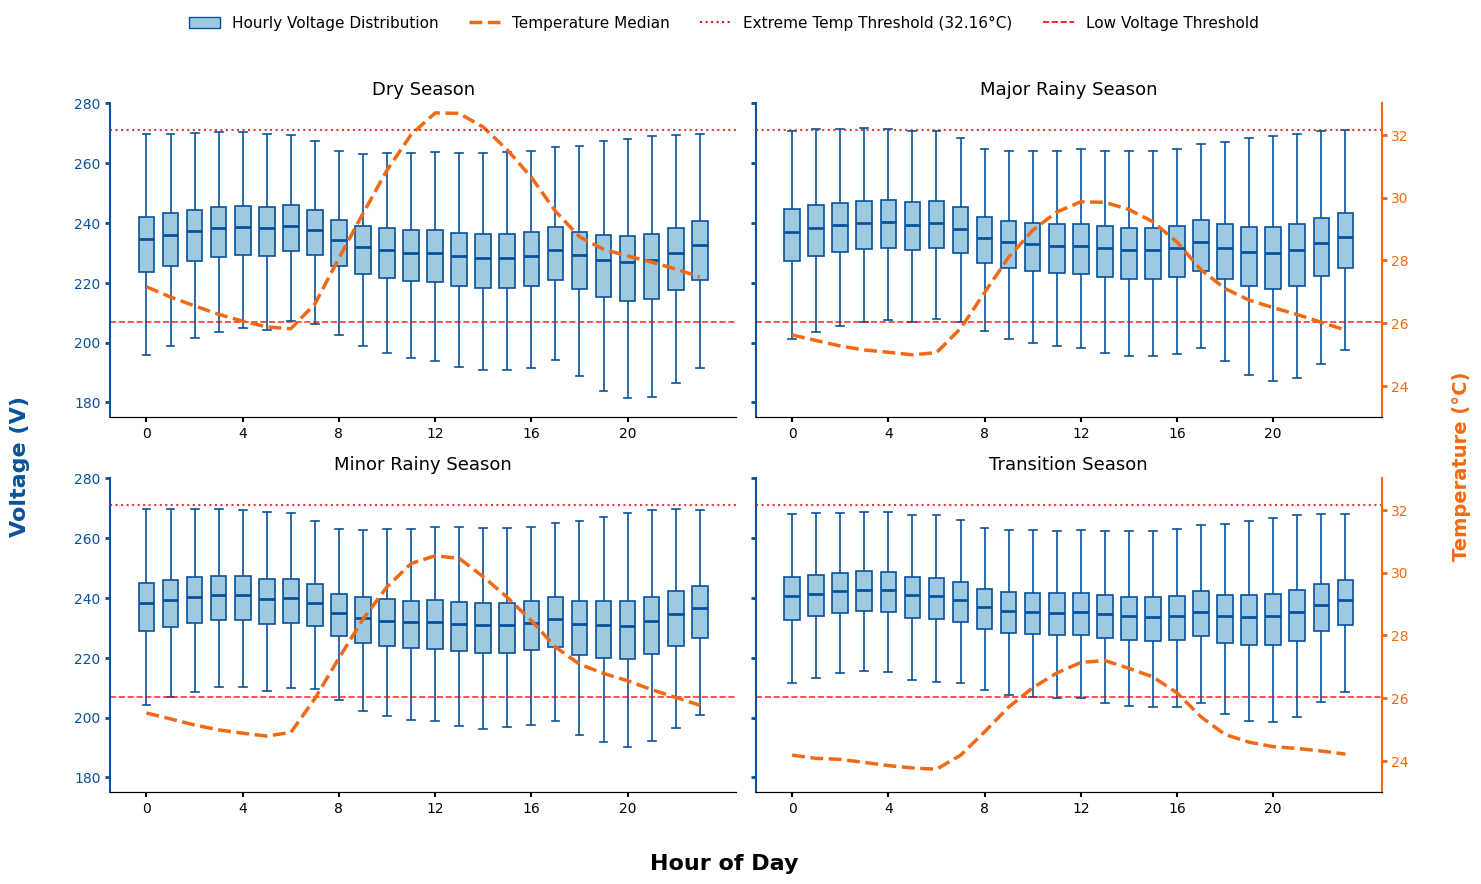

In [29]:
voltage_box_summary, temp_summary = plot_seasonal_hourly_voltage_boxplots(
    combined_hourly_voltage_df,
    season_col='season_detailed',
    cesi_level=None,
    plot_temp=True,
    ylim=(175, 280),
    temp_ylim=(23, 33),
    temp_linestyle='--',
    legend_bbox=(0.5, 1.08), 
    
    show_lower_bound=True, lower_bound_color='red',    lower_bound_linestyle='--',
    show_upper_bound=False, upper_bound_color='purple',  upper_bound_linestyle=':',
    # save_path='hourly_volt_by_quarter_v1.png',
    save_path = PLOTS_DIR / 'hourly_volt_by_quarter_v1.png'
)

## *** Stats 

### How frequent are the undervoltage excursions? (percentage of hours below 207 volts)

In [30]:
def summarise_undervoltage_by_season(
    df,
    season_col='season_detailed',
    voltage_col='voltage',
    threshold=207,
    ignore_zero=True,
) -> pd.DataFrame:
    """
    Summarise undervoltage exposure by season.

    Parameters
    ----------
    df : pd.DataFrame
        Hourly voltage DataFrame with columns: time, site_id, voltage,
        season_detailed (or equivalent), and optionally cesi_level.
    season_col : str
        Column to group by for seasons.
    voltage_col : str
        Column containing voltage readings.
    threshold : float
        Undervoltage threshold in volts. Default is 207V (230V ± 10%).
    ignore_zero : bool
        If True, exclude zero-voltage readings (outage periods) before
        computing statistics.

    Returns
    -------
    pd.DataFrame
        One row per season with undervoltage summary statistics.
    """
    plot_df = df.copy()

    if ignore_zero:
        plot_df = plot_df[plot_df[voltage_col] != 0]

    plot_df = plot_df.dropna(subset=[voltage_col, season_col])

    def _season_stats(grp):
        total_hours = len(grp)
        n_below = (grp[voltage_col] < threshold).sum()
        pct_below = (n_below / total_hours) * 100 if total_hours > 0 else np.nan
        return pd.Series({
            'n_hours':         total_hours,
            'n_below_207V':    n_below,
            'pct_below_207V':  round(pct_below, 2),
        })

    summary = (
        plot_df
        .groupby(season_col)
        .apply(_season_stats)
        .reset_index()
    )

    return summary

In [31]:
undervoltage_summary = summarise_undervoltage_by_season(combined_hourly_voltage_df)

In [32]:
undervoltage_summary

,season_detailed,n_hours,n_below_207V,pct_below_207V
0,Dry_Season,2042670.0,160164.0,7.84
1,Major_Rainy_Season,2031584.0,122415.0,6.03
2,Minor_Rainy_Season,1535047.0,81129.0,5.29
3,Transition_Season,526348.0,15821.0,3.01


### How bad are the undervoltage excursions, when they happen? 

In [33]:
def summarise_undervoltage_severity_by_season(
    df,
    season_col='season_detailed',
    voltage_col='voltage',
    threshold=207,
) -> pd.DataFrame:
    """
    Descriptive statistics on undervoltage excursion magnitude, by season.
    Restricted to hours where voltage is non-zero, non-null, and below threshold.

    Parameters
    ----------
    df : pd.DataFrame
        Hourly voltage DataFrame with columns: time, site_id, voltage,
        season_detailed (or equivalent).
    season_col : str
        Column to group by for seasons.
    voltage_col : str
        Column containing voltage readings.
    threshold : float
        Undervoltage threshold in volts. Default is 207V (230V ± 10%).

    Returns
    -------
    pd.DataFrame
        One row per season with descriptive statistics on excursion voltages.
    """
    plot_df = (
        df
        .dropna(subset=[voltage_col, season_col])
        .pipe(lambda d: d[d[voltage_col] != 0])
        .pipe(lambda d: d[d[voltage_col] < threshold])
        .copy()
    )

    summary = (
        plot_df
        .groupby(season_col)[voltage_col]
        .agg(
            n_excursions='count',
            mean='mean',
            median='median',
            std='std',
            q25=lambda x: x.quantile(0.25),
            q75=lambda x: x.quantile(0.75),
            min='min',
            max='max',
        )
        .assign(IQR=lambda x: x['q75'] - x['q25'])
        .round(2)
        .reset_index()
    )

    return summary

In [34]:
undervoltage_severity = summarise_undervoltage_severity_by_season(combined_hourly_voltage_df)

In [36]:
undervoltage_severity

,season_detailed,n_excursions,mean,median,std,q25,q75,min,max,IQR
0,Dry_Season,160164,188.96,197.78,33.50,189.13,203.25,23.34,206.99,14.12
1,Major_Rainy_Season,122415,186.61,198.18,38.07,188.59,203.42,23.34,206.99,14.83
2,Minor_Rainy_Season,81129,187.04,198.26,38.43,189.84,203.39,23.47,206.99,13.55
3,Transition_Season,15821,182.11,199.06,45.65,187.58,203.61,24.14,206.99,16.03
